# Entrenamiento modelo predicción de salario

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('../data/interim/df_merged.csv')
df = df.dropna(subset=['Rango_Salarial'])

df.drop(columns=['experiencia','años_experiencia'], inplace=True)

In [2]:
df.shape

(19982, 7)

In [3]:
df['Rango_Salarial'].value_counts()

Rango_Salarial
65.000-80.000      3788
<15.000            3435
15.000-22.000      2873
80.000-100.000     2295
30.000-40.000      2027
22.000-30.000      1967
40.000-52.000      1243
100.000-150.000    1177
52.000-65.000       992
>150.000            185
Name: count, dtype: int64

In [4]:
#mapeo los rangos salariales a números para entrenar los modelos correctamente
df['Rango_Salarial'] = df['Rango_Salarial'].map({'<15.000': 0, '15.000-22.000': 1, '22.000-30.000': 2, '30.000-40.000': 3, '40.000-52.000': 4, '52.000-65.000': 5, '65.000-80.000': 6, '80.000-100.000': 7, '100.000-150.000': 8, '>150.000': 9})
df['Rango_Salarial'].value_counts()

Rango_Salarial
6    3788
0    3435
1    2873
7    2295
3    2027
2    1967
4    1243
8    1177
5     992
9     185
Name: count, dtype: int64

In [5]:
df.head()

,formación_académica,sector,tipo_de_empleo,Ciudad,Salario_medio,Rango_Salarial,id
0,Grado Universitario,"Salud, Farmacia y Tecnología Médica",Media jornada,Madrid,25000.0,2,0
1,Ninguna,Servicios,Jornada completa,Madrid,43200.0,4,1
2,Grado Universitario,Economía y política,Jornada completa,Madrid,13200.0,0,2
3,Ninguna,Transporte y Logística,NaN,Madrid,131112.0,8,3
4,Ninguna,Economía y política,Jornada completa,Madrid,15144.0,1,4


## 1. Declarar X e y

In [6]:
X = df.drop(columns=['Rango_Salarial'])
y = df['Rango_Salarial']
# no borro aun Salario_medio para eliminar outliers

## 2. Dividir en train y test

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 3. Feature Engineering

### Valores faltantes

In [8]:
X_train.isnull().sum()

formación_académica        0
sector                     0
tipo_de_empleo         10101
Ciudad                  3156
Salario_medio              0
id                         0
dtype: int64

Por ahora voy a mantener los nulos, ya que modelos como XGBoost o Random Forest pueden trabajar con valores nulos.

### Outliers

La variable salario tiene outliers que pueden afectar al rendimiento del modelo (EDA)

In [9]:
X_train.shape, X_test.shape

((15985, 6), (3997, 6))

In [10]:
IQR = X_train['Salario_medio'].quantile(0.75) - X_train['Salario_medio'].quantile(0.25)
lower = X_train['Salario_medio'].quantile(0.25) - 1.5 * IQR
upper = X_train['Salario_medio'].quantile(0.75) + 1.5 * IQR
X_train = X_train[(X_train['Salario_medio'] >= lower) & (X_train['Salario_medio'] <= upper)]
y_train = y_train[X_train.index]

X_test = X_test[(X_test['Salario_medio'] >= lower) & (X_test['Salario_medio'] <= upper)]
y_test = y_test[X_test.index]

In [11]:
X_train.shape, X_test.shape

((15843, 6), (3960, 6))

In [12]:
# Ya no necesito el salario medio
X_train = X_train.drop(columns=['Salario_medio'])
X_test = X_test.drop(columns=['Salario_medio'])

### Encode variables categoricas

In [13]:
X_train[['formación_académica','sector','tipo_de_empleo','Ciudad']]

,formación_académica,sector,tipo_de_empleo,Ciudad
32227,FP Medio,Bienes de consumo,NaN,Madrid
23221,Ninguna,Comercio minorista y comercio,NaN,Bilbao
29613,Ninguna,Tecnología y telecomunicaciones,NaN,Madrid
27205,Ninguna,Transporte y Logística,NaN,NaN
25053,Grado Universitario,Construcción,NaN,Valencia
...,...,...,...,...
27407,Ninguna,Servicios,NaN,Barcelona
31851,Ninguna,Deportes y recreación,NaN,Girona
23548,Ninguna,Servicios,Jornada completa,NaN
29337,Ninguna,Servicios,NaN,NaN


In [14]:
pd.get_dummies(X_train['formación_académica'], prefix='formacion', drop_first=True, dummy_na=True).astype(int).head()

,formacion_FP Medio,formacion_FP Superior,formacion_Grado Universitario,formacion_Ninguna,formacion_Postgrado,formacion_nan
32227,1,0,0,0,0,0
23221,0,0,0,1,0,0
29613,0,0,0,1,0,0
27205,0,0,0,1,0,0
25053,0,0,1,0,0,0


In [15]:
pd.get_dummies(X_train['sector'], prefix='sector', drop_first=True).astype(int).head()

,sector_Bienes de consumo,sector_Comercio electrónico,sector_Comercio minorista y comercio,sector_Construcción,sector_Deportes y recreación,sector_Economía y política,sector_Energía y medio ambiente,sector_Finanzas y seguros,sector_Internet,sector_Medios de comunicación,sector_Metales y electrónica,sector_Productos químicos y recursos,sector_Publicidad y Marketing,"sector_Salud, Farmacia y Tecnología Médica",sector_Servicios,sector_Sociedad,sector_Tecnología y telecomunicaciones,sector_Transporte y Logística,"sector_Viajes, turismo y hostelería"
32227,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23221,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
29613,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
27205,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
25053,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [16]:
pd.get_dummies(X_train['tipo_de_empleo'], prefix='tipo_empleo', drop_first=True, dummy_na=True).astype(int).head()

,tipo_empleo_Jornada completa,tipo_empleo_Media jornada,tipo_empleo_Otro,tipo_empleo_Prácticas,tipo_empleo_Temporal,tipo_empleo_nan
32227,0,0,0,0,0,1
23221,0,0,0,0,0,1
29613,0,0,0,0,0,1
27205,0,0,0,0,0,1
25053,0,0,0,0,0,1


In [17]:
X_train = pd.concat([X_train.drop(columns=['formación_académica','sector','tipo_de_empleo','Ciudad']),
                     pd.get_dummies(X_train['formación_académica'], prefix='formacion', drop_first=True, dummy_na=True).astype(int),
                     pd.get_dummies(X_train['sector'], prefix='sector', drop_first=True).astype(int),
                     pd.get_dummies(X_train['tipo_de_empleo'], prefix='tipo_empleo', drop_first=True, dummy_na=True).astype(int)], axis=1)

In [18]:
X_train.head()

,id,formacion_FP Medio,formacion_FP Superior,formacion_Grado Universitario,formacion_Ninguna,formacion_Postgrado,formacion_nan,sector_Bienes de consumo,sector_Comercio electrónico,sector_Comercio minorista y comercio,...,sector_Sociedad,sector_Tecnología y telecomunicaciones,sector_Transporte y Logística,"sector_Viajes, turismo y hostelería",tipo_empleo_Jornada completa,tipo_empleo_Media jornada,tipo_empleo_Otro,tipo_empleo_Prácticas,tipo_empleo_Temporal,tipo_empleo_nan
32227,32227,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
23221,23221,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
29613,29613,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
27205,27205,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
25053,25053,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [19]:
X_test = pd.concat([X_test.drop(columns=['formación_académica','sector','tipo_de_empleo','Ciudad']),
                     pd.get_dummies(X_test['formación_académica'], prefix='formacion', drop_first=True, dummy_na=True).astype(int),
                     pd.get_dummies(X_test['sector'], prefix='sector', drop_first=True).astype(int),
                     pd.get_dummies(X_test['tipo_de_empleo'], prefix='tipo_empleo', drop_first=True, dummy_na=True).astype(int)], axis=1)

## 4. Feature Scaling

In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train.drop(columns=['id']))
X_test_scaled = scaler.transform(X_test.drop(columns=['id']))

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.drop(columns=['id']).columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.drop(columns=['id']).columns, index=X_test.index)

X_train = pd.concat([X_train_scaled, X_train['id']], axis=1)
X_test = pd.concat([X_test_scaled, X_test['id']], axis=1)

In [21]:
df_embeddings = pd.read_csv('../data/interim/df_embeddings.csv')
X_train = X_train.merge(df_embeddings, on='id', how='left')
X_test = X_test.merge(df_embeddings, on='id', how='left')

X_train = X_train.drop(columns=['id'])
X_test = X_test.drop(columns=['id'])

## 5. Entrenamiento de modelos

In [22]:
# Arreglar nombre de columnas para evitar problemas con los modelos
X_train.columns = X_train.columns.str.replace(',', '_')
X_test.columns = X_test.columns.str.replace(',', '_')

In [23]:
sets_posibles = [
    list(X_train.columns),
    list(X_train.drop(columns=['tipo_empleo_Jornada completa','tipo_empleo_Media jornada','tipo_empleo_Otro','tipo_empleo_Prácticas','tipo_empleo_Temporal','tipo_empleo_nan']).columns),
]

In [35]:
import scipy as sp
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import sklearn.metrics as metrics
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [25]:
# XGBoost, entrenado con GPU para acelerar el entrenamiento
xgb_model = xgb.XGBClassifier(random_state=42,
                              objective='multi:softprob',
                              eval_metric='mlogloss',
                              num_class=y_train.nunique(),
                              tree_method='hist',
                              device='cuda')

param_grid = {"n_estimators": [100, 150],
              'max_depth': sp.stats.randint(3, 15),
              'learning_rate': sp.stats.uniform(0.01, 0.2),
              'subsample': sp.stats.uniform(0.7, 0.3),
              'colsample_bytree': sp.stats.uniform(0.7, 0.3),
              'min_child_weight': sp.stats.randint(1, 10),
              'gamma': sp.stats.uniform(0, 5),
              'reg_alpha': sp.stats.uniform(0, 1),
              'reg_lambda': sp.stats.uniform(0.5, 2)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_model = RandomizedSearchCV(xgb_model,
                               param_grid,
                               n_iter=25,
                               cv=cv,
                               random_state=42,
                               scoring='f1_macro',
                               n_jobs=-1,
                               verbose=3
                               )


# LightGBM
lgb_model = lgb.LGBMClassifier(random_state=42,
                               objective='multiclass',
                               num_class=y_train.nunique(),
                               class_weight='balanced',
                               device_type='gpu')

param_grid = {"n_estimators": [100, 150],
              'max_depth': sp.stats.randint(3, 15),
              'learning_rate': sp.stats.uniform(0.01, 0.2),
              'num_leaves': sp.stats.randint(15, 80),
              'min_child_samples': sp.stats.randint(5, 50),
              'subsample': sp.stats.uniform(0.7, 0.3),
              'colsample_bytree': sp.stats.uniform(0.7, 0.3),
              'reg_alpha': sp.stats.uniform(0, 1),
              'reg_lambda': sp.stats.uniform(0.5, 2)
}

lgb_model = RandomizedSearchCV(lgb_model,
                               param_grid,
                               n_iter=25,
                               cv=cv,
                               random_state=42,
                               scoring='f1_macro',
                               n_jobs=-1,
                               verbose=3
                               )


# Random Forest
rfc = RandomForestClassifier(random_state=42, class_weight='balanced')
param_grid = {"n_estimators": [100, 150],
              'criterion': ['gini', 'entropy', 'log_loss'],
              'max_depth': sp.stats.randint(3, 50),
              'min_samples_split': sp.stats.randint(2, 15),
              'min_samples_leaf': sp.stats.randint(1, 15),
              'max_features': ['sqrt', 'log2', None]
}
rfc_model = RandomizedSearchCV(rfc,
                               param_grid,
                               n_iter=25,
                               cv=cv,
                               random_state=42,
                               scoring='f1_macro',
                               n_jobs=-1,
                               verbose=3
                               )

In [43]:
from pathlib import Path
import joblib

modelos = [xgb_model,lgb_model,rfc_model]
score_df = pd.DataFrame()
models_dir = Path('../models/salary')
models_dir.mkdir(parents=True, exist_ok=True)

for i, features in enumerate(sets_posibles):
    X_train_fit = X_train[features]
    X_test_fit = X_test[features]
    print(f'Set : {i+1} con {len(features)} features')
    for modelo in modelos:
        model_name = modelo.estimator.__class__.__name__
        model_path = models_dir / f'set_{i+1}_{model_name}.joblib'

        if model_path.exists():
            print(f'  Saltando {model_name} en set {i+1}: ya existe {model_path.name}')
            modelo = joblib.load(model_path)
            y_pred_train = modelo.predict(X_train_fit)
            y_pred_proba = modelo.predict_proba(X_test_fit)
            y_pred_test = modelo.predict(X_test_fit)

            accuracy_test = accuracy_score(y_test, y_pred_test)
            accuracy_train = accuracy_score(y_train, y_pred_train)

            auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted', labels=modelo.classes_)

            new_scores = pd.DataFrame({
                "Modelo": [model_name],
                "Feature set": [f'Set : {i+1} con {len(features)} features'],
                "Accuracy test": [accuracy_test],
                "Accuracy train": [accuracy_train],
                "AUC-ROC": [auc_roc]
            })
            score_df = pd.concat([score_df, new_scores], ignore_index=True)
            continue

        try:
            print(model_name) #imprimir el nombre del modelo
            modelo.fit(X_train_fit, y_train)

            # Guardar el modelo
            joblib.dump(modelo.best_estimator_, model_path)

            # Hacer predicciones
            y_pred_train = modelo.predict(X_train_fit)
            y_pred_proba = modelo.predict_proba(X_test_fit)
            y_pred_test = modelo.predict(X_test_fit)

            #Calcular accuracy
            accuracy_test = accuracy_score(y_test, y_pred_test)
            accuracy_train = accuracy_score(y_train, y_pred_train)

            #Calcular AUC-ROC
            auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

            #Crear dataframe
            new_scores = pd.DataFrame({
                "Modelo": [model_name],
                "Feature set": [f'Set : {i+1} con {len(features)} features'],
                "Accuracy test": [accuracy_test],
                "Accuracy train": [accuracy_train],
                "AUC-ROC": [auc_roc]
            })
            score_df = pd.concat([score_df, new_scores], ignore_index=True)
        except Exception as exc:
            print(f'  Error en {model_name} para set {i+1}: {exc}')
            continue
score_df

Set : 1 con 202 features
  Saltando XGBClassifier en set 1: ya existe set_1_XGBClassifier.joblib
  Saltando LGBMClassifier en set 1: ya existe set_1_LGBMClassifier.joblib
  Saltando RandomForestClassifier en set 1: ya existe set_1_RandomForestClassifier.joblib
Set : 2 con 196 features
  Saltando XGBClassifier en set 2: ya existe set_2_XGBClassifier.joblib
  Saltando LGBMClassifier en set 2: ya existe set_2_LGBMClassifier.joblib
  Saltando RandomForestClassifier en set 2: ya existe set_2_RandomForestClassifier.joblib


,Modelo,Feature set,Accuracy test,Accuracy train,AUC-ROC
0,XGBClassifier,Set : 1 con 202 features,0.866414,0.997286,0.986437
1,LGBMClassifier,Set : 1 con 202 features,0.865404,0.999053,0.985983
2,RandomForestClassifier,Set : 1 con 202 features,0.866162,0.992868,0.985401
3,XGBClassifier,Set : 2 con 196 features,0.853030,0.996150,0.983674
4,LGBMClassifier,Set : 2 con 196 features,0.855808,0.999558,0.983447
5,RandomForestClassifier,Set : 2 con 196 features,0.853030,0.994509,0.982192


In [45]:
score_df.sort_values(by='Accuracy test', ascending=False)

,Modelo,Feature set,Accuracy test,Accuracy train,AUC-ROC
0,XGBClassifier,Set : 1 con 202 features,0.866414,0.997286,0.986437
2,RandomForestClassifier,Set : 1 con 202 features,0.866162,0.992868,0.985401
1,LGBMClassifier,Set : 1 con 202 features,0.865404,0.999053,0.985983
4,LGBMClassifier,Set : 2 con 196 features,0.855808,0.999558,0.983447
3,XGBClassifier,Set : 2 con 196 features,0.853030,0.996150,0.983674
5,RandomForestClassifier,Set : 2 con 196 features,0.853030,0.994509,0.982192


## 6. Resultados y explicabilidad

In [50]:
import shap
import matplotlib.pyplot as plt
def resultados(model, X_train_model, X_test_model):
    y_pred_train = model.predict(X_train_model)
    y_pred_proba = model.predict_proba(X_test_model)
    y_pred_test = model.predict(X_test_model)

    auc_roc_test = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted', labels=model.classes_)
    auc_roc_train = roc_auc_score(y_train, model.predict_proba(X_train_model), multi_class='ovr', average='weighted',labels=model.classes_ )

    ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    cmap=plt.cm.Blues,
    values_format='.0f',
    )
    plt.show()

    display(pd.DataFrame(classification_report(y_test,y_pred_test, output_dict=True)).T)

    print(f'AUC-ROC test: {auc_roc_test:.4f}')
    print(f'AUC-ROC train: {auc_roc_train:.4f}')

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test_model)
    shap.summary_plot(shap_values.values, X_test_model, plot_type="bar")

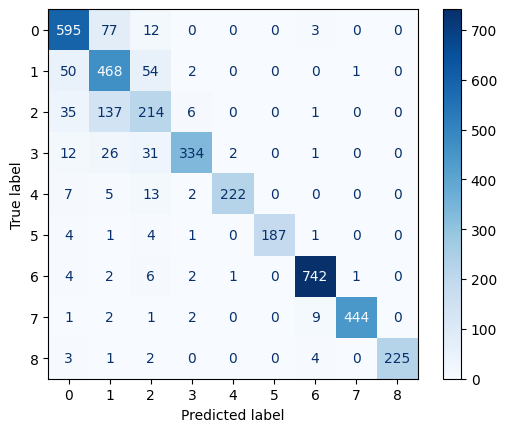

,precision,recall,f1-score,support
0,0.836850,0.866084,0.851216,687.000000
1,0.650904,0.813913,0.723338,575.000000
2,0.635015,0.544529,0.586301,393.000000
3,0.957020,0.822660,0.884768,406.000000
4,0.986667,0.891566,0.936709,249.000000
5,1.000000,0.944444,0.971429,198.000000
6,0.975033,0.978892,0.976959,758.000000
7,0.995516,0.967320,0.981215,459.000000
8,1.000000,0.957447,0.978261,235.000000
accuracy,0.866414,0.866414,0.866414,0.866414


AUC-ROC test: 0.9864
AUC-ROC train: 1.0000


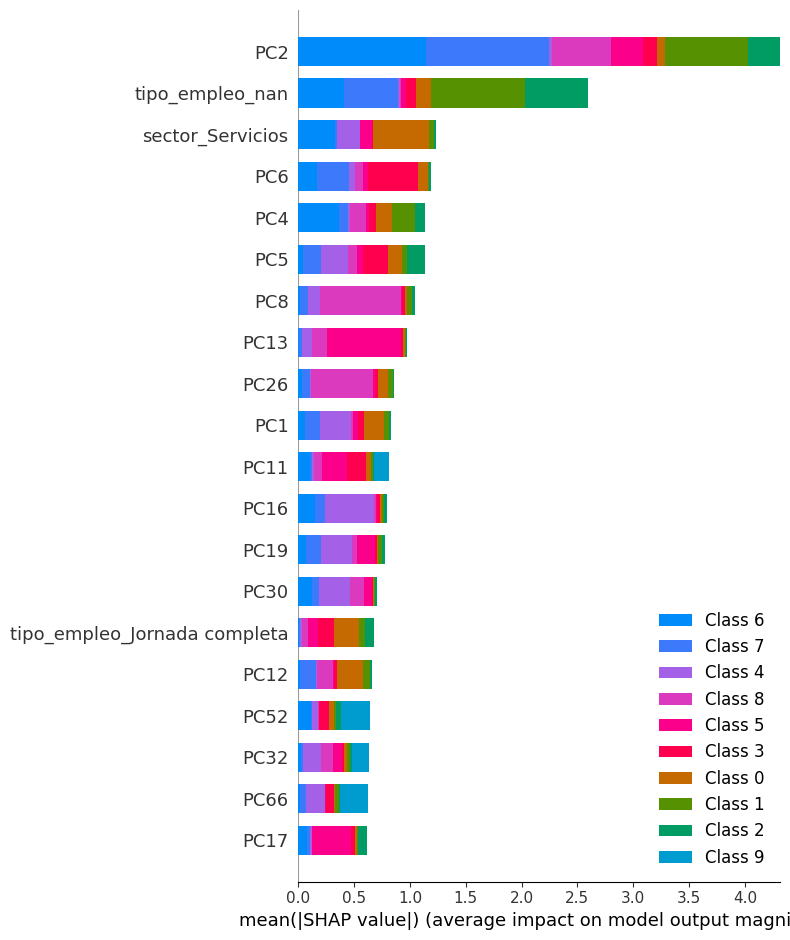

In [51]:
Xgb_set1 = joblib.load('../models/salary/set_1_XGBClassifier.joblib')
resultados(Xgb_set1, X_train[sets_posibles[0]], X_test[sets_posibles[0]])

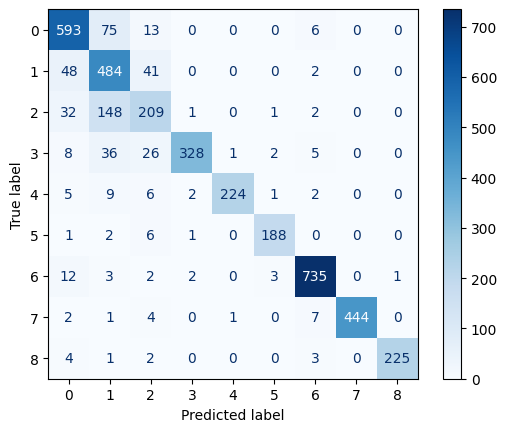

,precision,recall,f1-score,support
0,0.841135,0.863173,0.852011,687.000000
1,0.637681,0.841739,0.725637,575.000000
2,0.676375,0.531807,0.595442,393.000000
3,0.982036,0.807882,0.886486,406.000000
4,0.991150,0.899598,0.943158,249.000000
5,0.964103,0.949495,0.956743,198.000000
6,0.964567,0.969657,0.967105,758.000000
7,1.000000,0.967320,0.983389,459.000000
8,0.995575,0.957447,0.976139,235.000000
accuracy,0.866162,0.866162,0.866162,0.866162


AUC-ROC test: 0.9854
AUC-ROC train: 0.9999


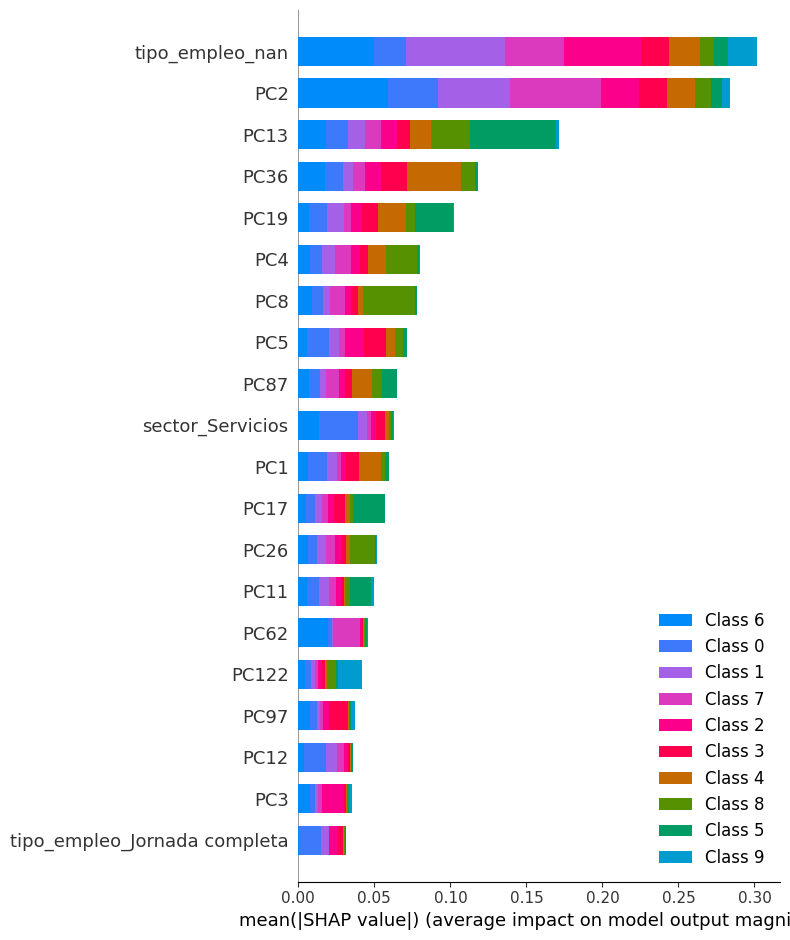

In [52]:
rfc_set1 = joblib.load('../models/salary/set_1_RandomForestClassifier.joblib') 
resultados(rfc_set1, X_train[sets_posibles[0]], X_test[sets_posibles[0]])

Los modelos están aprendiendo que que el tipo de empleo nulo es un buen predictor.

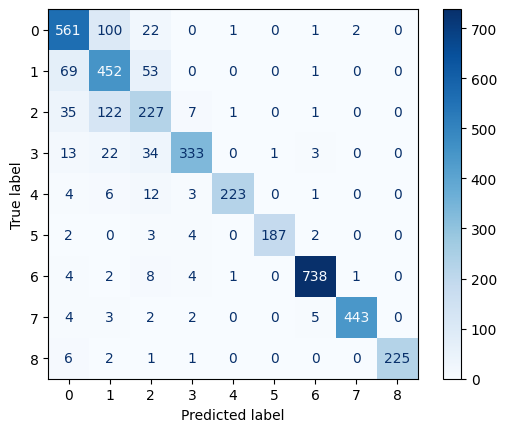

,precision,recall,f1-score,support
0,0.803725,0.816594,0.810108,687.000000
1,0.637518,0.786087,0.704050,575.000000
2,0.627072,0.577608,0.601325,393.000000
3,0.940678,0.820197,0.876316,406.000000
4,0.986726,0.895582,0.938947,249.000000
5,0.994681,0.944444,0.968912,198.000000
6,0.981383,0.973615,0.977483,758.000000
7,0.993274,0.965142,0.979006,459.000000
8,1.000000,0.957447,0.978261,235.000000
accuracy,0.855808,0.855808,0.855808,0.855808


AUC-ROC test: 0.9834
AUC-ROC train: 1.0000


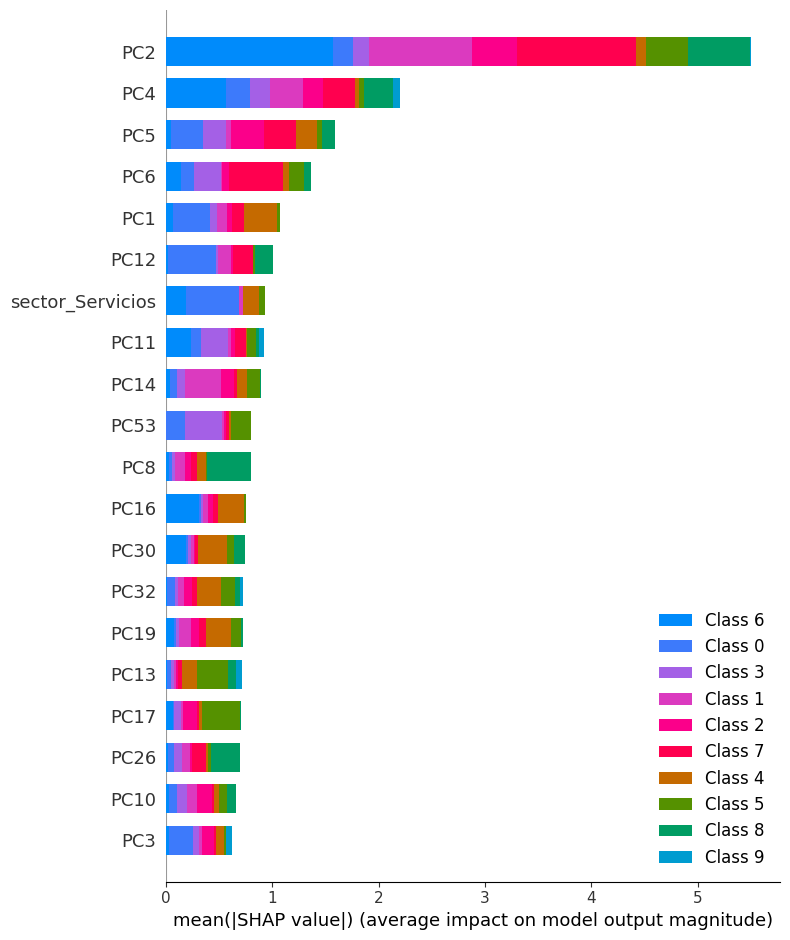

In [55]:
lgb_set2 = joblib.load('../models/salary/set_2_LGBMClassifier.joblib')
resultados(lgb_set2, X_train[sets_posibles[1]], X_test[sets_posibles[1]])